# Comparison

Cross-model summary built from each notebook's `results.json`. All three models were trained on the same 5 folds so the comparison is paired.

## Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
from src.utils.config.config import Config
from src.classifier.common import results
from src.classifier.common.constants import ACTION_NAMES

## Load

In [4]:
config_loader = Config()
cfg = config_loader.load_config()
runs = cfg.project_root / "runs"

# Map display name to results.json path
MODEL_PATHS = {
    "MLP":  runs / "single_frame" / "results.json",
    "LSTM": runs / "lstm" / "results.json",
    "GNN":  runs / "gnn" / "results.json",
}

loaded = {}
for name, path in MODEL_PATHS.items():
    if not path.exists():
        print(f"skipping {name}: {path} not found")
        continue
    loaded[name] = results.load(path)

print(f"loaded: {list(loaded.keys())}")

loaded: ['MLP', 'LSTM', 'GNN']


## Per class F1 with std across folds

mean ± std across the 5 folds for each class and model. macro is the unweighted mean across the 4 classes.

In [5]:
# Returns dict: class_name -> (mean, std) across folds for one model
def fold_f1_stats(payload):
    per_fold = {name: [] for name in payload["action_names"]}
    for rep in payload["fold_reports"]:
        for name in payload["action_names"]:
            per_fold[name].append(rep[name]["f1"])
    out = {n: (float(np.mean(v)), float(np.std(v))) for n, v in per_fold.items()}
    macro_per_fold = [np.mean([rep[n]["f1"] for n in payload["action_names"]])
                      for rep in payload["fold_reports"]]
    out["macro"] = (float(np.mean(macro_per_fold)), float(np.std(macro_per_fold)))
    return out

stats = {name: fold_f1_stats(p) for name, p in loaded.items()}

rows = list(stats[next(iter(stats))].keys())
table = pd.DataFrame(index=rows, columns=loaded.keys())
for name, s in stats.items():
    for cls, (m, sd) in s.items():
        table.at[cls, name] = f"{m:.3f} ± {sd:.3f}"
table

,MLP,LSTM,GNN
idle,0.975 ± 0.010,0.992 ± 0.006,0.989 ± 0.007
using_laptop,0.925 ± 0.085,0.942 ± 0.082,0.942 ± 0.082
using_phone,0.965 ± 0.011,0.988 ± 0.011,0.983 ± 0.011
reading,0.953 ± 0.024,0.976 ± 0.019,0.974 ± 0.018
macro,0.954 ± 0.023,0.975 ± 0.020,0.972 ± 0.018


## Bar chart

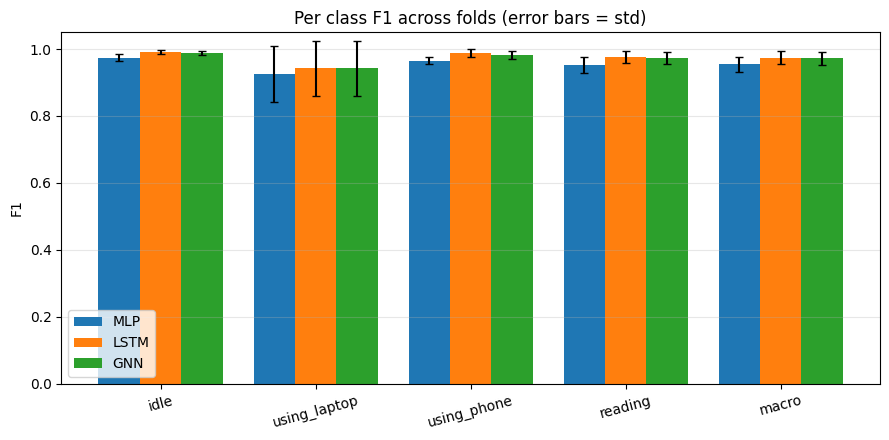

In [6]:
classes = ACTION_NAMES + ["macro"]
model_names = list(loaded.keys())
x = np.arange(len(classes))
width = 0.8 / max(1, len(model_names))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, name in enumerate(model_names):
    means = [stats[name][c][0] for c in classes]
    stds  = [stats[name][c][1] for c in classes]
    offset = (i - (len(model_names) - 1) / 2) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=3, label=name)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15)
ax.set_ylabel("F1")
ax.set_ylim(0, 1.05)
ax.set_title("Per class F1 across folds (error bars = std)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion matrices side by side

Each panel is summed across all 5 folds and row-normalized so the diagonal shows per-class recall.

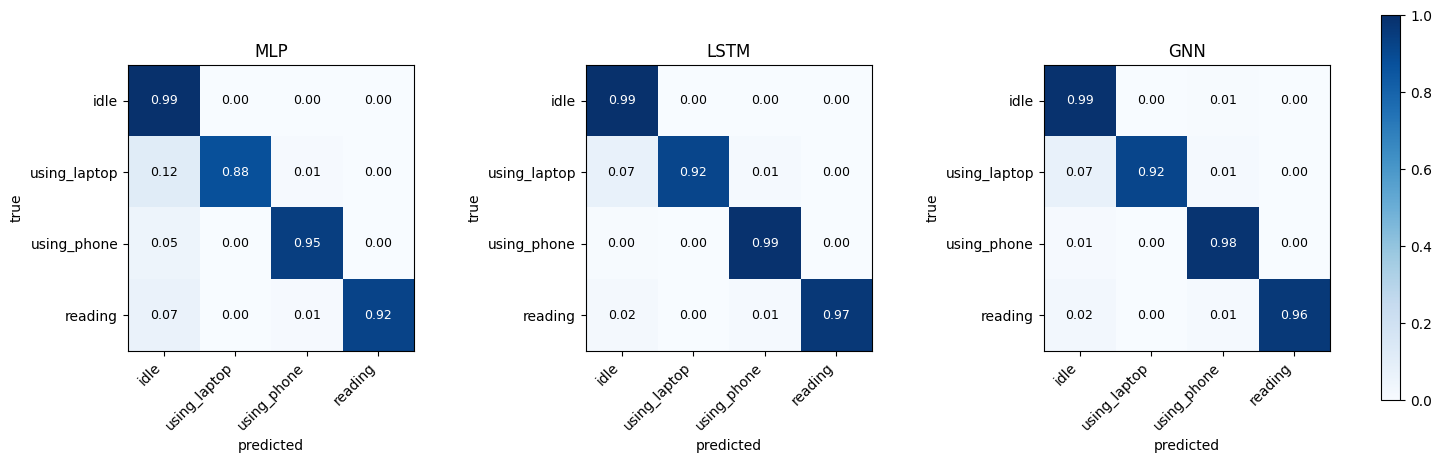

In [9]:
def aggregated_cm(payload):
    cms = [np.asarray(cm) for cm in payload["fold_cms"]]
    return sum(cms)

def row_normalize(cm):
    row_sums = cm.sum(axis=1, keepdims=True)
    return cm / np.where(row_sums == 0, 1, row_sums)

n = len(loaded)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5))
if n == 1:
    axes = [axes]

for ax, (name, payload) in zip(axes, loaded.items()):
    cm = aggregated_cm(payload)
    norm = row_normalize(cm)
    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(ACTION_NAMES)))
    ax.set_yticks(range(len(ACTION_NAMES)))
    ax.set_xticklabels(ACTION_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(ACTION_NAMES)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(name)

    for i in range(len(ACTION_NAMES)):
        for j in range(len(ACTION_NAMES)):
            ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center",
                    color="white" if norm[i, j] > 0.5 else "black", fontsize=9)

plt.subplots_adjust(wspace=0.6)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
plt.show()

## Raw count confusion tables

In [8]:
for name, payload in loaded.items():
    cm = aggregated_cm(payload)
    df = pd.DataFrame(cm, index=ACTION_NAMES, columns=ACTION_NAMES)
    df.index.name = "true \\ pred"
    print(f"\n=== {name} ===")
    print(df)


=== MLP ===
              idle  using_laptop  using_phone  reading
true \ pred                                           
idle          6146             8           21        9
using_laptop    25           189            2        0
using_phone    150             8         2876        9
reading        102             0           18     1424

=== LSTM ===
              idle  using_laptop  using_phone  reading
true \ pred                                           
idle          1975             3            6        3
using_laptop     5            65            1        0
using_phone      4             3          977        3
reading         10             0            6      488

=== GNN ===
              idle  using_laptop  using_phone  reading
true \ pred                                           
idle          1971             3           10        3
using_laptop     5            65            1        0
using_phone     11             3          970        3
reading         12       